*@author: petra.boskovic*

## Emotion Recognition: Natural Language Processing with TensorFlow

## Task 1: Setup and Imports

In [3]:
#!pip install nlp
#!pip install datasets
#!pip install tensorflow

In [4]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import nlp
import random

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from google.colab import drive, files, userdata

import warnings
warnings.filterwarnings('ignore')

In [5]:
drive.mount('/content/drive')

path = '/content/drive/MyDrive/Colab Notebooks/data science/deep learning/'

Mounted at /content/drive


In [6]:
pd.set_option('display.max_columns', None)

In [7]:
def show_history(h):
    epochs_trained = len(h.history['loss'])
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 2, 1)
    plt.plot(range(0, epochs_trained), h.history.get('accuracy'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_accuracy'), label='Validation')
    plt.ylim([0., 1.])
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(range(0, epochs_trained), h.history.get('loss'), label='Training')
    plt.plot(range(0, epochs_trained), h.history.get('val_loss'), label='Validation')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()


def show_confusion_matrix(y_true, y_pred, classes):
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y_true, y_pred, normalize='true')

    plt.figure(figsize=(8, 8))
    sp = plt.subplot(1, 1, 1)
    ctx = sp.matshow(cm)
    plt.xticks(list(range(0, 6)), labels=classes)
    plt.yticks(list(range(0, 6)), labels=classes)
    plt.colorbar(ctx)
    plt.show()

## Task 2: Importing Data:

1. Importing the Emotion dataset
2. Creating train, validation and test sets
3. Extracting text and labels from the examples

In [8]:
df = load_dataset("dair-ai/emotion", "split")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [9]:
df

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

### **Label dictionary**
'0': **sadness**  
'1': **joy**  
'2': **love**  
'3': **anger**  
'4': **fear**  
'5': **surprise**

In [10]:
train = df['train']
val = df['validation']
test = df['test']

In [11]:
def get_text(data):
  text = [x['text'] for x in data]
  labels = [x['label'] for x in data]
  return text, labels

In [12]:
text, labels = get_text(train)

In [13]:
text[1], labels[1]

('i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake',
 0)

## Task 3: Tokenizer

In [14]:
tokenizer = Tokenizer(num_words=10000, oov_token='<UNK>')
tokenizer.fit_on_texts(text)

In [15]:
tokenizer.texts_to_sequences([text[0]])

[[2, 139, 3, 679]]

In [16]:
text[0]

'i didnt feel humiliated'

## Task 4: Padding and Truncating Sequences

1. Checking length of the text
2. Creating padded sequences

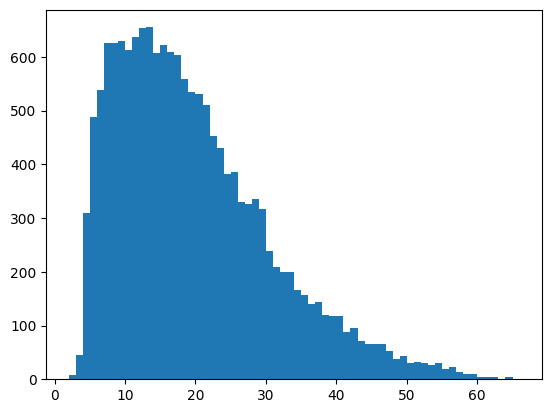

In [17]:
lengths = [len(t.split(' ')) for t in text]
plt.hist(lengths, bins = len(set(lengths)))
plt.show()

In [18]:
def get_sequences(tokenizer, text):
  sequences = tokenizer.texts_to_sequences(text)
  padded = pad_sequences(sequences, truncating= 'post', padding= 'post', maxlen= 50)
  return padded

In [19]:
padded_train_seq = get_sequences(tokenizer, text)
padded_train_seq[0]  # there is 50 values

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

## Task 5: Preparing the Labels

1. Creating classes to index and index to classes dictionaries
2. Converting text labels to numeric labels

In [20]:
classes = set(labels)
classes

{0, 1, 2, 3, 4, 5}

In [28]:
index_to_class = {
    0: 'sadness',
    1: 'joy',
    2: 'love',
    3: 'anger',
    4: 'fear',
    5: 'surprise'
}

index_to_class

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}

In [31]:
class_to_index = {v: k for k, v in index_to_class.items()}
class_to_index

{'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}

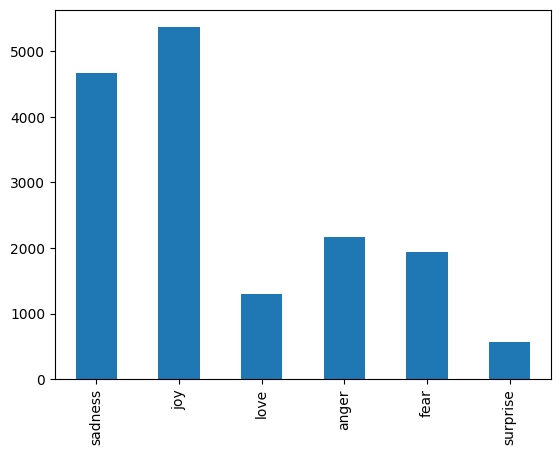

In [34]:
s = pd.Series(labels)

s_named = s.map(index_to_class)

counts = s_named.value_counts().reindex(list(index_to_class.values()))

counts.plot(kind='bar')
plt.show()